In [2]:
from msi.msi import MSI
from diff_prof.diffusion_profiles import DiffusionProfiles
import multiprocessing
import numpy as np
import pickle
import networkx as nx
import polars as pl
import gc
import seaborn as sns
import matplotlib.pyplot as plt
#import paramiko

from filter_logic import filter_drug_protein_edges
from tests.msi import test_msi
from tests.diff_prof import test_diffusion_profiles

In [ ]:
# Selective loading example (low RAM): compare a small set of drugs between
#  - baseline run saved under results/ (computed earlier), and
#  - one filtered run saved under results_filtered/<run_id>/
#
# This uses the original MSI developers' pattern:
#   dp = DiffusionProfiles(..., save_load_file_path=...)
#   msi.load_saved_node_idx_mapping_and_nodelist(dp.save_load_file_path)
#   dp.load_diffusion_profiles(selected_nodes)

import os
import numpy as np
import pandas as pd

from diff_prof import (
    compute_all_diffusion_profiles_for_msi_across_filtered_drug2protein_tsvs,
    diffusion_profile_similarity,
)

BASELINE_RUN_DIR = "results/"  # must already exist from a prior compute step
FILTERED_SAVE_ROOT = "results_filtered/"

if not (os.path.exists(os.path.join(BASELINE_RUN_DIR, "node2idx.pkl")) and os.path.exists(os.path.join(BASELINE_RUN_DIR, "graph.pkl"))):
    raise FileNotFoundError(
        f"Baseline run artifacts not found in {BASELINE_RUN_DIR!r}. "
        "Run your baseline diffusion computation first so results/node2idx.pkl and results/graph.pkl exist."
    )

# Discover available filtered runs without loading profiles into RAM
runs_filtered = compute_all_diffusion_profiles_for_msi_across_filtered_drug2protein_tsvs(
    save_root=FILTERED_SAVE_ROOT,
    drug2protein_glob="data/1_drug_to_protein_filtered_*cutoff_*.tsv",
    recompute=False,
    on_error="skip",
)

run_ids = sorted(runs_filtered.keys())
print(f"Discovered filtered runs: {len(run_ids)}")
if not run_ids:
    raise RuntimeError(
        "No filtered runs found on disk. Run the compute script first to populate results_filtered/<run_id>/."
    )

In [10]:
# Compare DEFAULT run vs ALL filtered runs (parallel per-drug, low RAM)
#
# Strategy:
# - Loop over each run_id
# - For each run: compute common drugs + common node intersection indices
# - Load diffusion profiles in CHUNKS (bounded RAM) using the original MSI pattern
# - Compute per-drug L2 similarity in parallel with threads (not multiprocessing)

import os
import gc
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

BASELINE_RUN_DIR = "results/"  # must already exist from a prior compute step

if not (os.path.exists(os.path.join(BASELINE_RUN_DIR, "node2idx.pkl")) and os.path.exists(os.path.join(BASELINE_RUN_DIR, "graph.pkl"))):
    raise FileNotFoundError(
        f"Baseline run artifacts not found in {BASELINE_RUN_DIR!r}. "
        "Run baseline diffusion computation first so results/node2idx.pkl and results/graph.pkl exist."
    )

# Baseline MSI + DP loader
msi_default = MSI(drug2protein_file_path="data/1_drug_to_protein.tsv")
msi_default.load()

dp_default = DiffusionProfiles(
    alpha=None,
    max_iter=None,
    tol=None,
    weights=None,
    num_cores=None,
    save_load_file_path=BASELINE_RUN_DIR,
)
msi_default.load_saved_node_idx_mapping_and_nodelist(dp_default.save_load_file_path)

# Tuning knobs
CHUNK_SIZE = 300  # lower if RAM is tight
MAX_WORKERS = min(32, (os.cpu_count() or 1))

all_rows = []

drugs_default = set(msi_default.drugs_in_graph)

print(f"Comparing default MSI against {len(run_ids)} filtered runs...")

for i_run, run_id in enumerate(run_ids, start=1):
    run = runs_filtered[run_id]

    # Build MSI for this run (lightweight relative to loading all diffusion vectors)
    msi_run = MSI(drug2protein_file_path=run.drug2protein_file_path)
    msi_run.load()

    dp_run = DiffusionProfiles(
        alpha=None,
        max_iter=None,
        tol=None,
        weights=None,
        num_cores=None,
        save_load_file_path=run.save_load_file_path,
    )
    msi_run.load_saved_node_idx_mapping_and_nodelist(dp_run.save_load_file_path)

    drugs_run = set(msi_run.drugs_in_graph)
    common_drugs = sorted(drugs_default & drugs_run)
    if not common_drugs:
        continue

    # Precompute node intersection indices once per run
    common_nodes = [n for n in msi_default.nodelist if n in msi_run.node2idx]
    n_common = int(len(common_nodes))
    if n_common == 0:
        continue

    idx_a = np.fromiter((msi_default.node2idx[n] for n in common_nodes), dtype=np.int64)
    idx_b = np.fromiter((msi_run.node2idx[n] for n in common_nodes), dtype=np.int64)

    print(
        f"[{i_run}/{len(run_ids)}] {run_id}: common_drugs={len(common_drugs)}, common_nodes={n_common}"
    )

    def _chunks(lst, size):
        for j in range(0, len(lst), size):
            yield lst[j : j + size]

    for chunk in _chunks(common_drugs, CHUNK_SIZE):
        # Selectively load ONLY this chunk
        dp_default.load_diffusion_profiles(chunk)
        dp_run.load_diffusion_profiles(chunk)

        profiles_default = dp_default.drug_or_indication2diffusion_profile
        profiles_run = dp_run.drug_or_indication2diffusion_profile

        def _one(drug_id: str):
            a = profiles_default[drug_id][idx_a]
            b = profiles_run[drug_id][idx_b]
            dist = float(np.linalg.norm(a - b, ord=2))
            sim = 1.0 / (1.0 + dist)
            return {
                "run_id": run_id,
                "drug_id": drug_id,
                "similarity_l2": sim,
                "l2_distance": dist,
                "n_common_nodes": n_common,
                "drug2protein_file_path": run.drug2protein_file_path,
            }

        # Threaded per-drug compute (avoids multiprocessing spawn issues)
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            for row in ex.map(_one, chunk):
                all_rows.append(row)

        # Free chunk memory aggressively
        dp_default.drug_or_indication2diffusion_profile = {}
        dp_run.drug_or_indication2diffusion_profile = {}
        gc.collect()

# Final dataframe: one row per (run_id, drug_id)
df_all_runs_vs_default = pd.DataFrame(all_rows)
print("Rows:", len(df_all_runs_vs_default))

# Convenience summary per run
if len(df_all_runs_vs_default) > 0:
    df_run_summary = (
        df_all_runs_vs_default
        .groupby("run_id")["similarity_l2"]
        .agg(["count", "mean", "median", "min", "max"])
        .reset_index()
        .sort_values("mean", ascending=False)
        .reset_index(drop=True)
    )
else:
    df_run_summary = pd.DataFrame(columns=["run_id", "count", "mean", "median", "min", "max"])

df_run_summary.head(15)


Comparing default MSI against 43 filtered runs...
[1/43] 1_drug_to_protein_filtered_deepdta_cutoff_5: common_drugs=637, common_nodes=28935
[2/43] 1_drug_to_protein_filtered_deepdta_cutoff_6: common_drugs=445, common_nodes=28743
[3/43] 1_drug_to_protein_filtered_deepdta_cutoff_7: common_drugs=231, common_nodes=28529
[4/43] 1_drug_to_protein_filtered_deepdta_cutoff_8: common_drugs=55, common_nodes=28353
[5/43] 1_drug_to_protein_filtered_gat_gcn_cutoff_5: common_drugs=646, common_nodes=28944
[6/43] 1_drug_to_protein_filtered_gat_gcn_cutoff_6: common_drugs=411, common_nodes=28709
[7/43] 1_drug_to_protein_filtered_gat_gcn_cutoff_7: common_drugs=188, common_nodes=28486
[8/43] 1_drug_to_protein_filtered_gat_gcn_cutoff_8: common_drugs=48, common_nodes=28346
[9/43] 1_drug_to_protein_filtered_gcnnet_cutoff_5: common_drugs=658, common_nodes=28956
[10/43] 1_drug_to_protein_filtered_gcnnet_cutoff_6: common_drugs=432, common_nodes=28730
[11/43] 1_drug_to_protein_filtered_gcnnet_cutoff_7: common_drug

,run_id,count,mean,median,min,max
0,1_drug_to_protein_filtered_mltle_gin_cutoff_8,85,0.887658,0.873232,0.808701,0.990082
1,1_drug_to_protein_filtered_gnina_cutoff_-70,581,0.887641,0.884193,0.748776,0.994919
2,1_drug_to_protein_filtered_mltle_gcn_cutoff_8,77,0.884791,0.874795,0.762641,0.988777
3,1_drug_to_protein_filtered_smina_cutoff_-70,545,0.884359,0.879946,0.749142,0.994720
4,1_drug_to_protein_filtered_gold_cutoff_60,417,0.884022,0.879507,0.747374,0.993579
5,1_drug_to_protein_filtered_gnina_cutoff_-75,502,0.883949,0.880836,0.759647,0.994917
6,1_drug_to_protein_filtered_gcnnet_cutoff_5,658,0.883760,0.885580,0.755569,0.994792
7,1_drug_to_protein_filtered_ginconvnet_cutoff_5,677,0.882966,0.885716,0.755511,0.994645
8,1_drug_to_protein_filtered_ledock_cutoff_-50,333,0.882355,0.879625,0.764100,0.994332
9,1_drug_to_protein_filtered_gat_gcn_cutoff_5,646,0.882286,0.882213,0.754574,0.995589


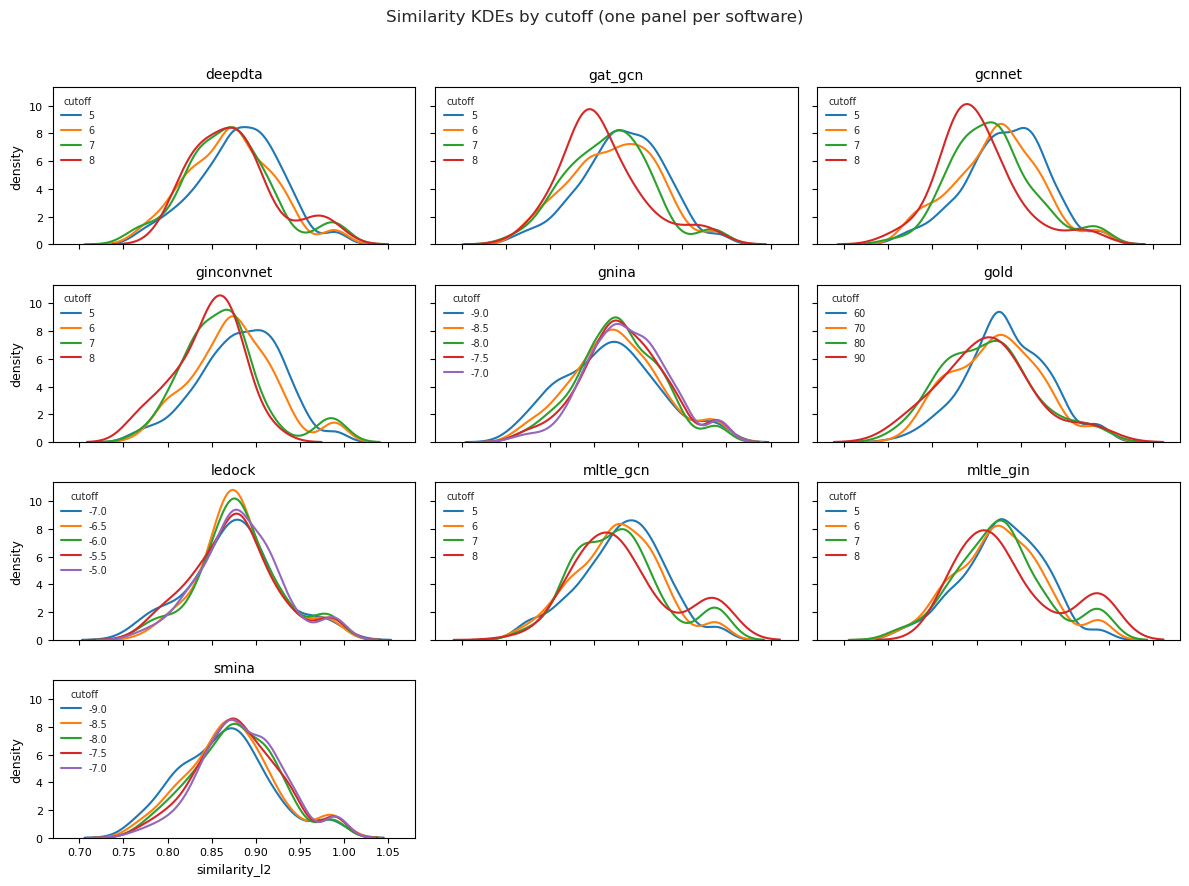

In [12]:
# KDE distributions of similarity_l2 per cutoff, faceted by software (4:3 slide friendly)

if len(df_all_runs_vs_default) == 0:
    raise RuntimeError("df_all_runs_vs_default is empty; run the comparison cell first.")

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_all_runs_vs_default.copy()

def _parse_software_cutoff(path: str):
    # Expect: .../1_drug_to_protein_filtered_<software>_cutoff_<cutoff>.tsv
    base = os.path.basename(str(path))
    m = re.search(r"filtered_(?P<sw>.+?)_cutoff_(?P<cut>.+?)\.tsv$", base)
    if not m:
        return None, None, None
    sw = m.group("sw")
    cut_str = m.group("cut")
    # numeric sort key if possible
    try:
        cut_val = float(cut_str)
    except Exception:
        cut_val = None
    return sw, cut_str, cut_val

parsed = df_plot["drug2protein_file_path"].apply(_parse_software_cutoff)
df_plot[["software", "cutoff", "cutoff_val"]] = pd.DataFrame(parsed.tolist(), index=df_plot.index)

# Keep only rows we can parse
df_plot = df_plot.dropna(subset=["software", "cutoff"]).copy()
if len(df_plot) == 0:
    raise RuntimeError(
        "Could not parse software/cutoff from drug2protein_file_path. "
        "Expected filenames like '...filtered_<software>_cutoff_<cutoff>.tsv'."
    )

# Order softwares and cutoffs (numeric if possible)
software_order = sorted(df_plot["software"].unique())

def _cutoff_sort_key(x: str):
    try:
        return float(x)
    except Exception:
        return float("inf")

# Layout for a 4:3 slide: aim for ~12x9 inches
n_softwares = len(software_order)
ncols = 3 if n_softwares >= 7 else 2
nrows = int(np.ceil(n_softwares / ncols))
fig_w, fig_h = 12, 9  # 4:3 ratio
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

palette = sns.color_palette("tab10", n_colors=10)
sns.set_style("whitegrid")

for ax_i, sw in enumerate(software_order):
    ax = axes[ax_i]
    sub = df_plot[df_plot["software"] == sw]
    # sort cutoffs for consistent legend ordering
    cutoffs = sorted(sub["cutoff"].unique(), key=_cutoff_sort_key)

    for j, cut in enumerate(cutoffs):
        sub2 = sub[sub["cutoff"] == cut]
        # KDE needs >=2 points to be meaningful
        if len(sub2) < 2:
            continue
        sns.kdeplot(
            data=sub2,
            x="similarity_l2",
            ax=ax,
            label=str(cut),
            color=palette[j % len(palette)],
            linewidth=1.5,
            fill=False,
            common_norm=False,
        )

    ax.set_title(sw, fontsize=10)
    ax.set_xlabel("similarity_l2", fontsize=9)
    ax.set_ylabel("density", fontsize=9)
    ax.tick_params(axis="both", which="major", labelsize=8)
    # Compact legend inside each panel
    ax.legend(title="cutoff", fontsize=7, title_fontsize=7, frameon=False, loc="upper left")

# Turn off any unused axes
for k in range(len(software_order), len(axes)):
    axes[k].axis("off")

fig.suptitle("Similarity KDEs by cutoff (one panel per software)", fontsize=12, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

In [ ]:
# Quick drill-down: pick the best mean-similarity run and show top 10 drugs for it

if len(df_run_summary) == 0:
    raise RuntimeError("df_run_summary is empty; run the comparison cell first.")

best_run_id = df_run_summary.iloc[0]["run_id"]
print("Best run by mean similarity:", best_run_id)

(df_all_runs_vs_default[df_all_runs_vs_default["run_id"] == best_run_id]
 .sort_values("similarity_l2", ascending=False)
 .head(10)
 .reset_index(drop=True)
)


### Reserved code (dumplings? :) )

In [ ]:
# Just some template code to demonstrate connection to remote server and read a parquet file
host = "headscale.bio-cloud.site"
username = "onur"
port = 50002
# password = "your_password_here"  # or use key-based authentication

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(host, username=username, password=password, port=port)  # add password/key args as needed
sftp = ssh.open_sftp()
remote_file = sftp.open("/media/onur/Elements/cavity_space_consensus_docking/2025_06_29_batch_dock/dta_atlas_data/home/madinasu/convertedData/dta_atlas_dataset_1_0/part.0.parquet", "rb")
df = pl.read_parquet(remote_file)
remote_file.close()
sftp.close()
ssh.close()